In [34]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Modelagem Preditiva da Potabilidade da Água

Este notebook tem como objetivo construir, comparar e otimizar modelos de Machine Learning para prever a variável `potabilidade`.

A etapa de análise exploratória dos dados foi realizada em outro arquivo. Portanto, este notebook foca em:

- carregamento dos dados tratados;
- separação entre treino e teste;
- tratamento do desbalanceamento com SMOTE;
- treinamento de modelos de classificação;
- comparação de métricas;
- otimização de hiperparâmetros;
- avaliação final do melhor modelo;
- salvamento do modelo final.

In [35]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================

caminho_dados = "../data/02-processed/dados-agua-tratados.csv"

tabela = pd.read_csv(caminho_dados)

print("Dimensão da base:", tabela.shape)
tabela.head()

Dimensão da base: (3276, 10)


,pH,dureza,std,cloraminas,sulfato,condutividade,carbono_orgânico,trihalometano,turbidez,potabilidade
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [36]:
# ============================================================
# 3. SEPARAÇÃO ENTRE VARIÁVEIS EXPLICATIVAS E VARIÁVEL-ALVO
# ============================================================

X = tabela.drop("potabilidade", axis=1)
y = tabela["potabilidade"]

print("Variáveis explicativas:", X.shape)
print("Variável-alvo:", y.shape)

Variáveis explicativas: (3276, 9)
Variável-alvo: (3276,)


In [37]:
# ============================================================
# 4. DISTRIBUIÇÃO DA VARIÁVEL-ALVO
# ============================================================

distribuicao_alvo = y.value_counts(normalize=True).rename("proporcao")
distribuicao_alvo

potabilidade
0    0.60989
1    0.39011
Name: proporcao, dtype: float64

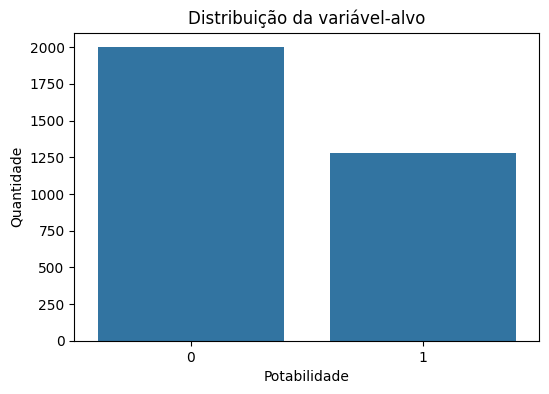

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribuição da variável-alvo")
plt.xlabel("Potabilidade")
plt.ylabel("Quantidade")
plt.show()

A variável-alvo apresenta possível desbalanceamento entre as classes.  
Por isso, será utilizado o SMOTE apenas dentro do processo de treinamento, evitando vazamento de dados para o conjunto de teste.

In [39]:
# ============================================================
# 5. SEPARAÇÃO ENTRE TREINO E TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2293, 9)
X_test: (983, 9)
y_train: (2293,)
y_test: (983,)


A separação foi feita com `stratify=y` para manter a proporção das classes nos conjuntos de treino e teste.

In [40]:
# ============================================================
# 6. DEFINIÇÃO DOS MODELOS BASE
# ============================================================

modelos_base = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    ),
    
    "LightGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
        force_col_wise=True
    ),
    
    "CatBoost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    )
}

In [41]:
# ============================================================
# 7. FUNÇÃO DE AVALIAÇÃO DOS MODELOS
# ============================================================

def avaliar_modelo(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    """
    Treina um modelo usando Pipeline com SMOTE e retorna as principais métricas.
    """
    
    pipeline = Pipeline(steps=[
        ("balanceamento", SMOTETomek(random_state=RANDOM_STATE)),
        ("modelo", modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    if hasattr(pipeline.named_steps["modelo"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    resultados = {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    }
    
    matriz_confusao = confusion_matrix(y_test, y_pred)
    
    return resultados, matriz_confusao, pipeline

In [42]:
# ============================================================
# 8. TREINAMENTO E COMPARAÇÃO DOS MODELOS BASE
# ============================================================

resultados_modelos = []
matrizes_confusao = {}
pipelines_treinados = {}

for nome, modelo in modelos_base.items():
    resultado, matriz, pipeline = avaliar_modelo(
        nome,
        modelo,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    resultados_modelos.append(resultado)
    matrizes_confusao[nome] = matriz
    pipelines_treinados[nome] = pipeline

resultados_df = pd.DataFrame(resultados_modelos)
resultados_df = resultados_df.sort_values(by="F1-score", ascending=False)

resultados_df

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
3,LightGBM,0.634791,0.532086,0.519582,0.525760,0.639978
4,CatBoost,0.631740,0.528000,0.516971,0.522427,0.670509
1,Gradient Boosting,0.596134,0.482759,0.511749,0.496831,0.626876
2,XGBoost,0.610376,0.500000,0.490862,0.495389,0.627772
0,Random Forest,0.621567,0.517134,0.433420,0.471591,0.640629


O F1-score foi utilizado como métrica principal porque combina precisão e recall, sendo útil em problemas de classificação com possível desbalanceamento entre classes.

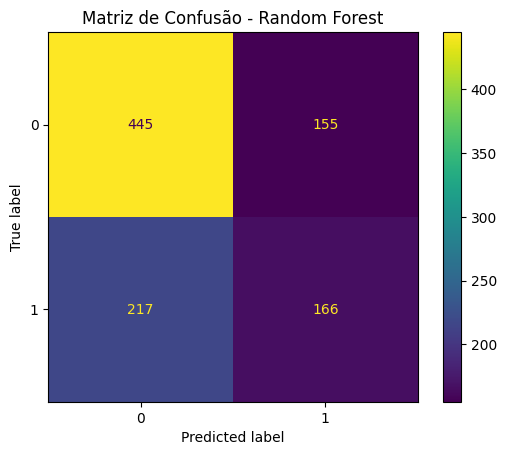

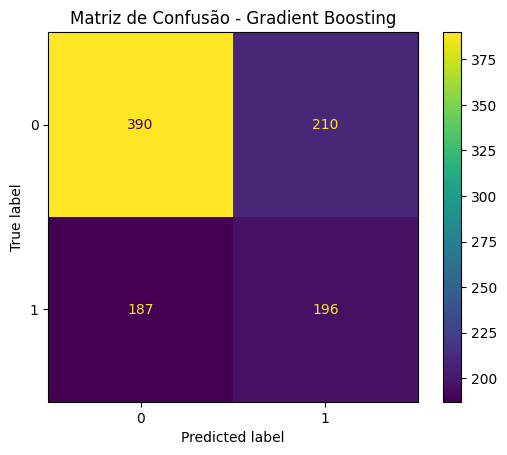

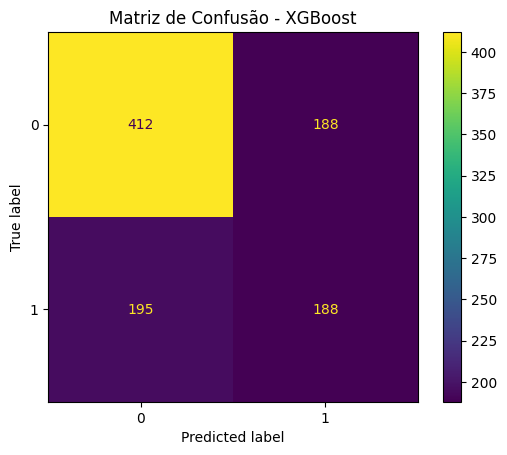

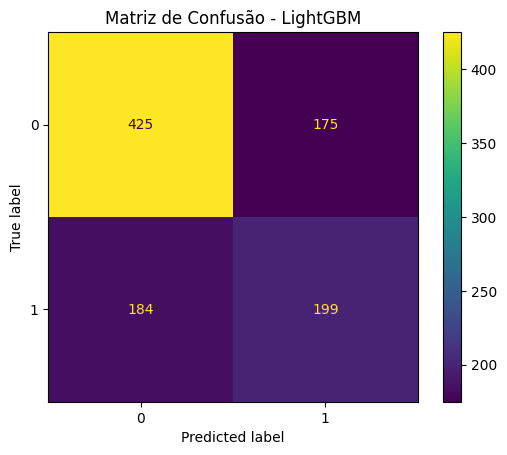

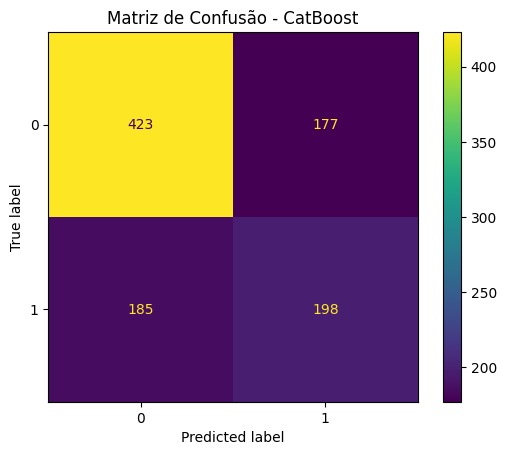

In [43]:
# ============================================================
# 9. MATRIZES DE CONFUSÃO DOS MODELOS BASE
# ============================================================

for nome, matriz in matrizes_confusao.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

In [44]:
# ============================================================
# 10. DEFINIÇÃO DOS HIPERPARÂMETROS PARA OTIMIZAÇÃO
# ============================================================

parametros_modelos = {
    "Random Forest": {
        "modelo": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "modelo__n_estimators": [100, 200, 500],
            "modelo__max_depth": [5, 10, 15, 20, None],
            "modelo__min_samples_split": [2, 5, 10,15,19],
            "modelo__max_features": ["sqrt", "log2"]
        }
    },
    
    "XGBoost": {
        "modelo": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            verbosity=0
        ),
        "params": {
            "modelo__n_estimators": [100, 300, 500],
            "modelo__max_depth": [3, 5, 7],
            "modelo__learning_rate": [0.001, 0.01, 0.1],
            "modelo__subsample": [0.6, 0.8, 1.0]
        }
    },
    
    "LightGBM": {
        "modelo": LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1,
            force_col_wise=True
        ),
        "params": {
            "modelo__n_estimators": [100, 200, 500],
            "modelo__max_depth": [3, 5, 8, -1],
            "modelo__learning_rate": [0.001, 0.01, 0.1]
        }
    },
    
    "CatBoost": {
        "modelo": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0
        ),
        "params": {
            "modelo__iterations": [200, 500, 1000],
            "modelo__learning_rate": [0.01, 0.03, 0.1],
            "modelo__depth": [4, 5, 8]
        }
    }
}

In [45]:
# ============================================================
# 11. OTIMIZAÇÃO DOS MODELOS COM RANDOMIZED SEARCH
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=RANDOM_STATE
)

resultados_otimizacao = []
melhores_modelos = {}

for nome_modelo, config in parametros_modelos.items():
    
    print(f"Otimizando modelo: {nome_modelo}")
    
    pipeline = Pipeline(steps=[
        ("balanceamento", SMOTETomek(random_state=RANDOM_STATE)),
        ("modelo", config["modelo"])
    ])
    
    busca = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=50,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    busca.fit(X_train, y_train)
    
    resultados_otimizacao.append({
        "Modelo": nome_modelo,
        "Melhor F1 médio CV": busca.best_score_,
        "Melhores parâmetros": busca.best_params_
    })
    
    melhores_modelos[nome_modelo] = busca.best_estimator_

resultados_otimizacao_df = pd.DataFrame(resultados_otimizacao)
resultados_otimizacao_df.sort_values(by="Melhor F1 médio CV", ascending=False)

Otimizando modelo: Random Forest
Otimizando modelo: XGBoost
Otimizando modelo: LightGBM
Otimizando modelo: CatBoost


,Modelo,Melhor F1 médio CV,Melhores parâmetros
3,CatBoost,0.558440,"{'modelo__learning_rate': 0.01, 'modelo__itera..."
0,Random Forest,0.547847,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
1,XGBoost,0.542161,"{'modelo__subsample': 0.8, 'modelo__n_estimato..."
2,LightGBM,0.532804,"{'modelo__n_estimators': 500, 'modelo__max_dep..."


A otimização foi feita com validação cruzada estratificada repetida.  
O SMOTE foi aplicado dentro do Pipeline, garantindo que o balanceamento ocorra apenas nos dados de treino de cada dobra da validação cruzada.

In [50]:
# ============================================================
# 12. AVALIAÇÃO FINAL DOS MODELOS OTIMIZADOS
# ============================================================

resultados_finais = []
matrizes_finais = {}

for nome, modelo in melhores_modelos.items():
    
    y_pred = modelo.predict(X_test)
    
    if hasattr(modelo.named_steps["modelo"], "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    resultados_finais.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })
    
    matrizes_finais[nome] = confusion_matrix(y_test, y_pred)

resultados_finais_df = pd.DataFrame(resultados_finais)
resultados_finais_df = resultados_finais_df.sort_values(by="F1-score", ascending=False)

resultados_finais_df

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
1,XGBoost,0.651068,0.556818,0.511749,0.533333,0.668455
2,LightGBM,0.627670,0.522788,0.509138,0.515873,0.643320
3,CatBoost,0.624619,0.519022,0.498695,0.508655,0.668351
0,Random Forest,0.625636,0.520661,0.493473,0.506702,0.660579


In [51]:
# ============================================================
# 13. SELEÇÃO DO MELHOR MODELO
# ============================================================

melhor_modelo_nome = resultados_finais_df.iloc[0]["Modelo"]
melhor_modelo = melhores_modelos[melhor_modelo_nome]

print("Melhor modelo:", melhor_modelo_nome)
print()
print(resultados_finais_df.iloc[0])

Melhor modelo: XGBoost

Modelo       XGBoost
Acurácia    0.651068
Precisão    0.556818
Recall      0.511749
F1-score    0.533333
ROC-AUC     0.668455
Name: 1, dtype: object


In [52]:
# ============================================================
# 14. RELATÓRIO DE CLASSIFICAÇÃO DO MELHOR MODELO
# ============================================================

y_pred_melhor = melhor_modelo.predict(X_test)

print(f"Relatório de classificação - {melhor_modelo_nome}")
print(classification_report(y_test, y_pred_melhor))

Relatório de classificação - XGBoost
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       600
           1       0.56      0.51      0.53       383

    accuracy                           0.65       983
   macro avg       0.63      0.63      0.63       983
weighted avg       0.65      0.65      0.65       983



In [53]:
# ============================================================
# 16. SALVAMENTO DO MELHOR MODELO
# ============================================================

caminho_modelo = "../depoly/melhor_modelo_potabilidade.pkl"

joblib.dump(melhor_modelo, caminho_modelo)

print(f"Modelo salvo em: {caminho_modelo}")

Modelo salvo em: ../depoly/melhor_modelo_potabilidade.pkl


# Conclusão

Neste notebook foram treinados e comparados diferentes modelos de classificação para prever a potabilidade da água.

O melhor modelo foi selecionado com base no F1-score, pois essa métrica equilibra precisão e recall, sendo adequada para problemas com possível desbalanceamento entre classes.

O uso do SMOTE foi realizado dentro de um Pipeline, evitando vazamento de dados durante o processo de validação cruzada e tornando a metodologia mais robusta.

## Próximos passos

- Comparar os resultados com a análise exploratória feita no outro notebook;
- Avaliar a importância das variáveis no melhor modelo;
- Testar novas estratégias de balanceamento;
- Ajustar o limiar de classificação;
- Validar o modelo com novos dados externos.